# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MihirJayswal812007/Flyrank-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

Ranked Actions & Reason Codes:

* Action: send_to_ux_design

* Reason Code: high_rank_low_ctr_comparison

* Mapping: When the model flags a comparison page that ranks in the top tiers but fails to capture clicks (CTR < 5%), it is added to a prioritized queue sorted by total impressions_90d. The highest-visibility failing pages are addressed first.

In [1]:
import pandas as pd
import numpy as np

# Load Data
url = "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

# Apply our core logic to generate the action queue
df['action_score'] = np.where(
    (df['content_type'].str.contains('comparison', case=False, na=False)) &
    (df['position_tier'].isin(['page_1', 'top_3'])) &
    (df['ctr'] < 0.05),
    100, 0
)

df['reason_code'] = np.where(df['action_score'] == 100, 'high_rank_low_ctr_comparison', 'none')
df['action_label'] = np.where(df['action_score'] == 100, 'send_to_ux_design', 'none')

# Filter and sort the queue by highest impact (most impressions lost)
action_queue = df[df['action_score'] == 100].sort_values(by=['impressions_90d'], ascending=False)

print(f"Total pages flagged for UI/UX review: {len(action_queue)}")
display(action_queue[['content_type', 'position_tier', 'ctr', 'impressions_90d', 'action_label']].head())

Total pages flagged for UI/UX review: 365


,content_type,position_tier,ctr,impressions_90d,action_label
17062,comparison article,page_1,0.01,11905,send_to_ux_design
6537,comparison article,page_1,0.00,6594,send_to_ux_design
9628,comparison article,page_1,0.02,6570,send_to_ux_design
9414,comparison article,page_1,0.02,4618,send_to_ux_design
34,comparison article,page_1,0.03,3998,send_to_ux_design


## 2. Intended use and limits

Intended Use: To serve as a decision-support queue for the UX and Content teams, helping them prioritize which high-traffic pages need immediate layout auditing and structural redesigns.

Limits: The model cannot account for "zero-click" search intent—queries where users get their answer directly from the Google snippet and intentionally do not click.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

Human Review: A UX researcher must manually review the flagged URLs to confirm the layout is genuinely outdated or poorly structured before assigning engineering hours to rebuild it.

The No-Go List: DO NOT automate page deletions, redirects, or immediate code changes based on this score. DO NOT apply this playbook to pages with fewer than 100 impressions in the last 90 days, as the CTR metric is too noisy at that volume.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

Monitoring: Track the "acceptance rate"—what percentage of the model's flagged queue does the design team actually agree requires a redesign?

Retrain Triggers: The model should be retrained every 6 months, or immediately following a major Google Core Update that alters how search snippets are displayed (which would fundamentally shift baseline CTRs).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exported action queue to: work/outputs/content_action_queue.csv
Exported research figure to: work/figures/ctr_distribution_plot.png


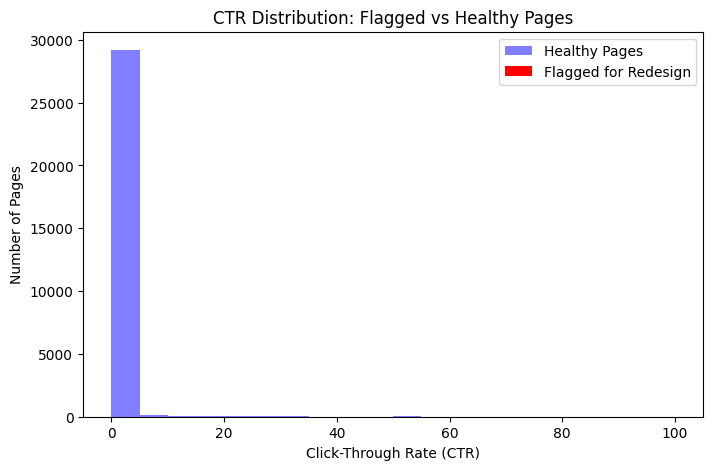

In [2]:
import os
import matplotlib.pyplot as plt

# Create output directories for our paper assets
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# 1. Export the Queue
action_queue.to_csv('work/outputs/content_action_queue.csv', index=False)
print("Exported action queue to: work/outputs/content_action_queue.csv")

# 2. Export a Figure for the Research Paper
plt.figure(figsize=(8, 5))
plt.hist(df[df['action_score'] == 0]['ctr'], bins=20, alpha=0.5, label='Healthy Pages', color='blue')
plt.hist(action_queue['ctr'], bins=10, alpha=1.0, label='Flagged for Redesign', color='red')
plt.title('CTR Distribution: Flagged vs Healthy Pages')
plt.xlabel('Click-Through Rate (CTR)')
plt.ylabel('Number of Pages')
plt.legend()

fig_path = 'work/figures/ctr_distribution_plot.png'
plt.savefig(fig_path)
print(f"Exported research figure to: {fig_path}")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.